# 04 - Is the uncertainty any good?

Dice says nothing about whether a model's confidence can be trusted. A segmenter
that reports 0.9 on pixels it gets right 60% of the time cannot be used to route
ambiguous cases to a human, which is the main clinical reason to want
uncertainty at all.

Two separate questions:

1. **Is the confidence numerically honest?** ECE, its equal-mass variant ACE,
   Brier, NLL, and the reliability diagram.
2. **Does the uncertainty rank the errors?** The sparsification curve and AUSE.
   Discard the most-uncertain pixels progressively and compare the remaining
   error against an oracle that discards the actually-wrong ones. AUSE is the
   normalised gap to that oracle, so it is invariant to the uncertainty's scale
   and lets vacuity, dissonance, softmax entropy and MC-dropout spread be
   compared directly.

This notebook trains a small evidential model and a softmax control, then
interrogates both.

In [1]:
# Run from the repository root, or from notebooks/ - both work.
import sys, os
from pathlib import Path

root = Path.cwd()
if root.name == "notebooks":
    root = root.parent
    os.chdir(root)
sys.path.insert(0, str(root / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

torch.set_num_threads(max(1, (os.cpu_count() or 2)))
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
print("repo root :", root)
print("torch     :", torch.__version__, "| cuda:", torch.cuda.is_available())

repo root : F:\projects\new ai projects\evidential-semi-supervised-lesion-segmentation
torch     : 2.13.0+cpu | cuda: False


In [2]:
from evissl.config import load_config
from evissl.pipelines import run_training

SCALE = [
    "data.image_size=64", "data.train_size=400", "data.val_size=48",
    "data.test_size=120", "data.labeled_fraction=0.10",
    "data.batch_size=8", "data.mu=2", "model.width=16", "model.depth=3",
    "optim.epochs=14", "optim.steps_per_epoch=16",
    "loss.kl_anneal_epochs=6", "semi.rampup_epochs=5",
    "run.out_dir=results/scratch",
]

runs = {}
for name, config_path in [("evidential", "configs/evidential.yaml"),
                          ("fixmatch", "configs/fixmatch.yaml")]:
    cfg = load_config(config_path, SCALE + [f"run.name=uq_{name}"])
    runs[name] = run_training(cfg, keep_predictions=True)["result"]
    print(f"{name}: dice {runs[name].summary['dice']:.4f}")

19:02:41 | INFO    | uq_evidential | separable_unet | 0.249M params | 0.042 GMACs | {'dataset': 'synthetic', 'image_size': 64, 'n_train': 400, 'n_labeled': 40, 'n_unlabeled': 360, 'n_val': 48, 'n_test': 120, 'lesion_pixel_fraction': 0.1642}


19:02:57 | INFO    | run=uq_evidential method=evidential head=evidential epochs=14 steps/epoch=16 (3.2 passes over the labelled set) device=cpu


19:04:42 | INFO    | epoch 0 | loss=1.4514 | val_dice=0.4754  <- best | 102.9s


19:05:16 | INFO    | epoch 1 | loss=1.4263 | val_dice=0.5370  <- best | 32.9s


19:06:01 | INFO    | epoch 2 | loss=1.3932 | val_dice=0.5648  <- best | 43.6s


...

19:25:36 | INFO    | epoch 11 | loss=0.5381 | val_dice=0.7359 | 39.2s


19:26:18 | INFO    | epoch 12 | loss=0.5230 | val_dice=0.7382  <- best | 40.7s


19:26:58 | INFO    | epoch 13 | loss=0.5118 | val_dice=0.7395  <- best | 38.1s


19:26:58 | INFO    | done: best val_dice=0.7395 at epoch 13


fixmatch: dice 0.7468


## Reliability

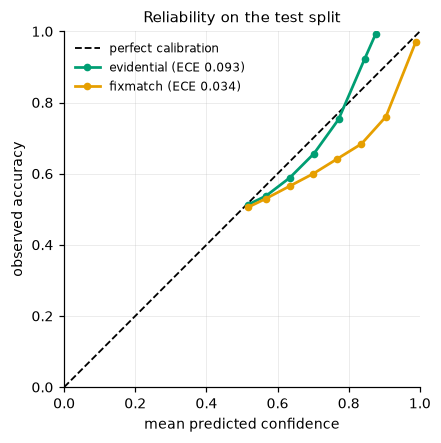

,evidential,fixmatch
ece,0.0930,0.0336
ace,0.0931,0.0341
mce,0.1168,0.1520
brier,0.0657,0.0597
nll,0.2595,0.2093
ause,0.1572,0.1517
unc_error_auroc,0.8842,0.8849


In [3]:
from evissl.metrics import expected_calibration_error
from evissl.viz import plot_reliability

curves, eces = {}, {}
for name, result in runs.items():
    predictions = result.predictions
    probability = predictions.prob.ravel()
    target = predictions.target.ravel()
    predicted = (probability >= 0.5).astype(float)
    confidence = np.where(predicted > 0.5, probability, 1.0 - probability)
    correct = (predicted == target).astype(float)
    curve = expected_calibration_error(confidence, correct, bins=15)
    curves[name], eces[name] = curve, curve["ece"]

fig = plot_reliability(curves, eces, title="Reliability on the test split")
plt.show()

display(pd.DataFrame({
    name: {k: result.calibration[k]
           for k in ("ece", "ace", "mce", "brier", "nll", "ause", "unc_error_auroc")}
    for name, result in runs.items()
}).round(4))

`ece` uses equal-width bins and `ace` equal-mass bins. For segmentation the two
can diverge sharply: almost every pixel is confidently background, so under
equal-width binning nearly all of them land in the top bin and the estimator
collapses towards a single average, hiding miscalibration in the sparse middle.
When `ace` is much larger than `ece`, that is what happened.

## Sparsification: does uncertainty find the errors?

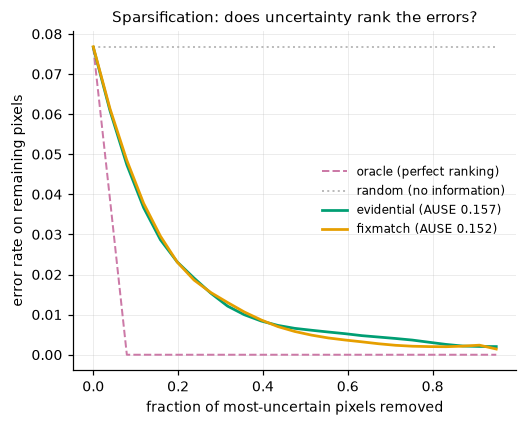

In [4]:
from evissl.eval import sparsification_for
from evissl.viz import plot_sparsification

sparsification = {name: sparsification_for(result, steps=25)
                  for name, result in runs.items()}
auses = {name: result.calibration["ause"] for name, result in runs.items()}
fig = plot_sparsification(sparsification, auses)
plt.show()

### Which uncertainty component ranks errors best?

The evidential head gives three candidate signals from a single forward pass.
Comparing them tells us *why* the uncertainty works, not just that it does.

In [5]:
from evissl.metrics import ause, uncertainty_error_auroc

predictions = runs["evidential"].predictions
correct = (predictions.binarize() == predictions.target).astype(float)
error = 1.0 - correct

signals = {
    "vacuity (epistemic)": predictions.vacuity,
    "dissonance (aleatoric)": predictions.dissonance,
    "vacuity + dissonance": np.clip(predictions.vacuity + predictions.dissonance, 0, 1),
    "predictive entropy": predictions.entropy,
    "softmax margin  1-|2p-1|": 1.0 - np.abs(predictions.prob - 0.5) * 2.0,
}
rows = [{"signal": name,
         "AUSE (lower better)": ause(signal, error),
         "AUROC (higher better)": uncertainty_error_auroc(signal, error)}
        for name, signal in signals.items() if signal is not None]
display(pd.DataFrame(rows).round(4).set_index("signal"))

,AUSE (lower better),AUROC (higher better)
signal,,
vacuity (epistemic),0.1565,0.8850
dissonance (aleatoric),0.1700,0.8779
vacuity + dissonance,0.1572,0.8842
predictive entropy,0.1572,0.8842
softmax margin 1-|2p-1|,0.1572,0.8842


## Where the uncertainty lives, spatially

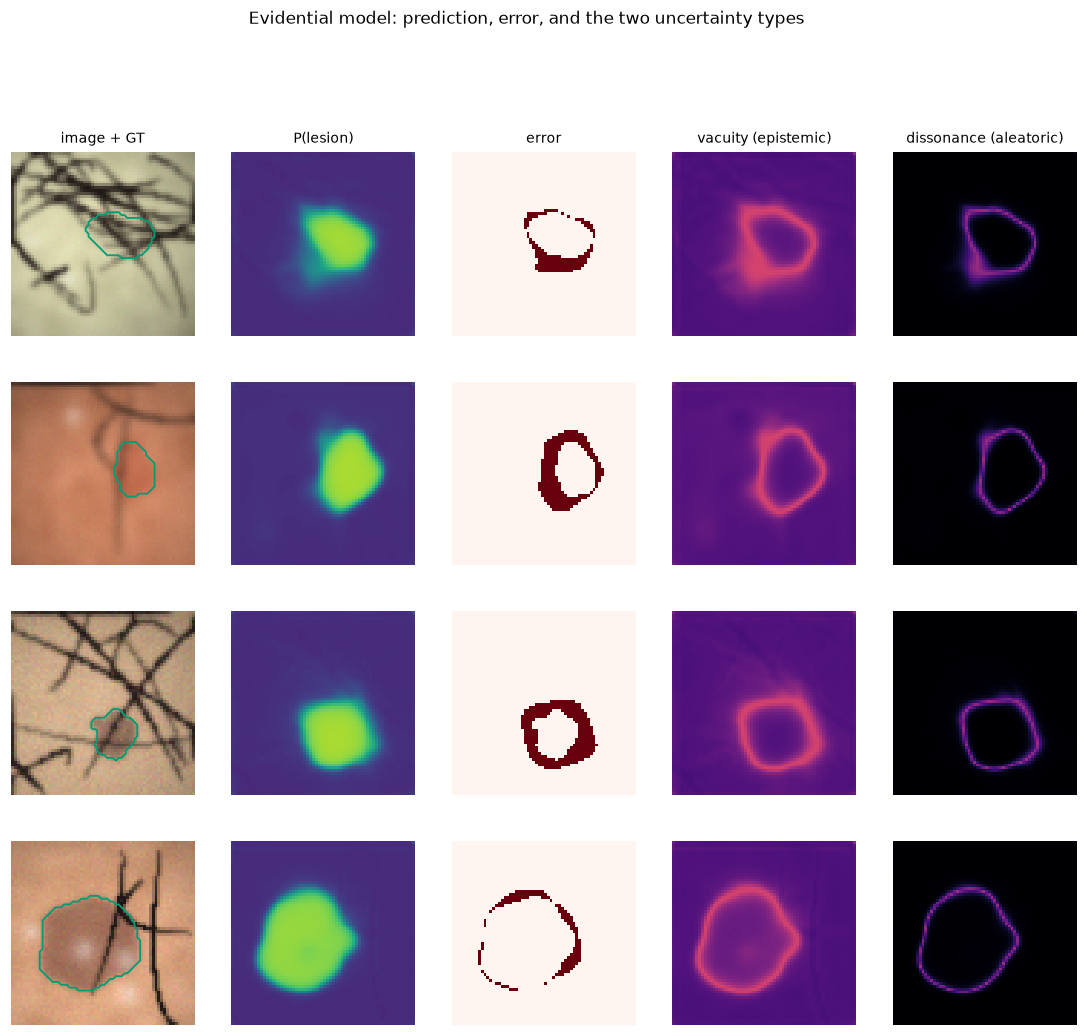

In [6]:
from evissl.data import build_dataset
from evissl.viz import plot_qualitative, plot_uncertainty_separation

cfg = load_config("configs/evidential.yaml", SCALE + ["run.name=uq_evidential"])
bundle = build_dataset(cfg.data, cfg.run.seed)

fig = plot_qualitative(
    bundle.test.images, predictions.target, predictions.prob,
    predictions.vacuity, predictions.dissonance, n=4,
    title="Evidential model: prediction, error, and the two uncertainty types",
)
plt.show()

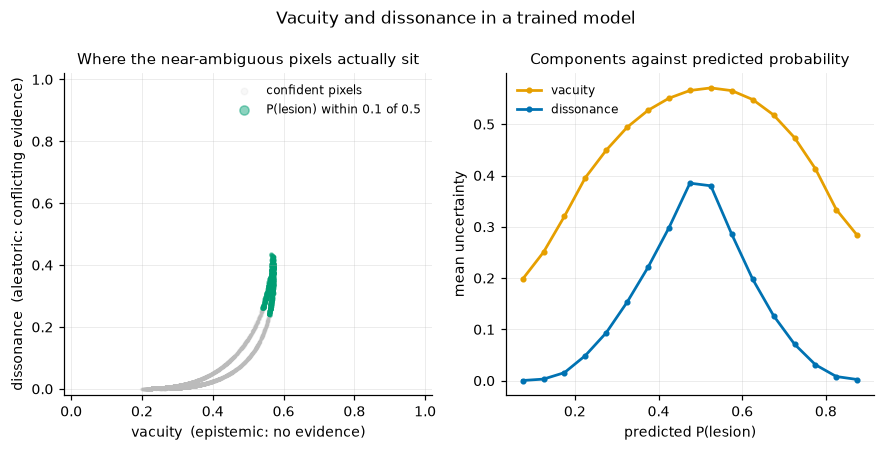

In [7]:
fig = plot_uncertainty_separation(
    predictions.vacuity, predictions.dissonance, predictions.prob
)
plt.show()

The left panel is the trained counterpart of the analytic argument in notebook
01. Among pixels whose predicted probability sits near 0.5, both axes should be
populated - some are uncertain because the model has no evidence, others because
the evidence genuinely conflicts. A confidence threshold cannot tell them apart;
this model can.

## Does uncertainty track the generator's difficulty?

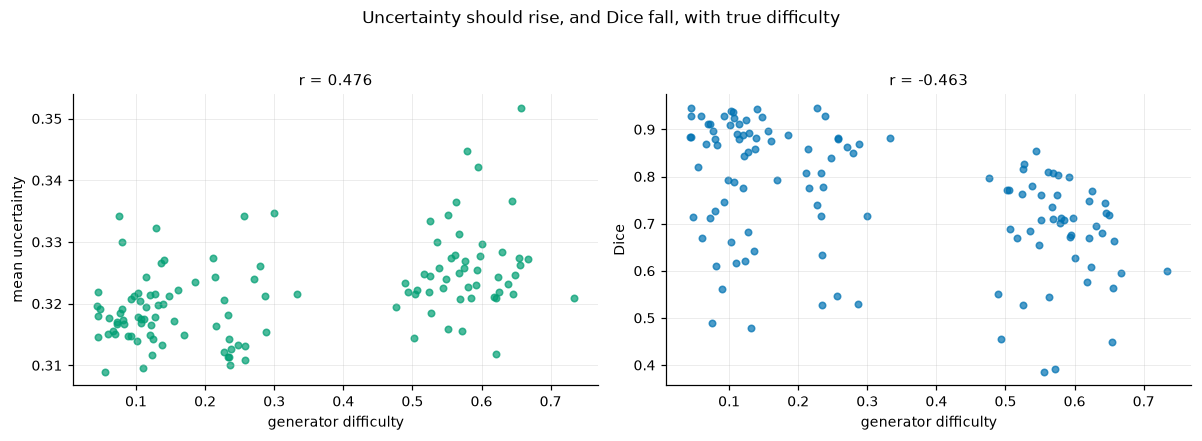

In [8]:
# The synthetic generator records the latent factors behind each image, so
# uncertainty can be validated against ground-truth difficulty - something a
# real dataset cannot offer.
difficulty = bundle.test.difficulty
per_image_uncertainty = predictions.primary_uncertainty().reshape(len(difficulty), -1).mean(1)
per_image_dice = runs["evidential"].metric_array("dice")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].scatter(difficulty, per_image_uncertainty, s=18, alpha=0.7, color="#009E73")
axes[0].set_xlabel("generator difficulty"); axes[0].set_ylabel("mean uncertainty")
axes[0].set_title(f"r = {np.corrcoef(difficulty, per_image_uncertainty)[0,1]:.3f}")
axes[1].scatter(difficulty, per_image_dice, s=18, alpha=0.7, color="#0072B2")
axes[1].set_xlabel("generator difficulty"); axes[1].set_ylabel("Dice")
axes[1].set_title(f"r = {np.corrcoef(difficulty, per_image_dice)[0,1]:.3f}")
fig.suptitle("Uncertainty should rise, and Dice fall, with true difficulty", y=1.04)
plt.tight_layout(); plt.show()

## The cost of an uncertainty estimate

In [9]:
from evissl.config import ModelConfig
from evissl.models import build_model
from evissl.utils.complexity import measure_latency

model = build_model(ModelConfig(name="separable_unet", width=16, depth=3))
single = measure_latency(model, (3, 64, 64), 1, repeats=20)["median_ms"]
display(pd.DataFrame([
    {"method": "evidential head", "forward passes": 1, "latency_ms": single,
     "gives epistemic/aleatoric split": True},
    {"method": "MC dropout (8)", "forward passes": 8, "latency_ms": single * 8,
     "gives epistemic/aleatoric split": True},
    {"method": "4-flip TTA", "forward passes": 4, "latency_ms": single * 4,
     "gives epistemic/aleatoric split": False},
]).round(2).set_index("method"))

,forward passes,latency_ms,gives epistemic/aleatoric split
method,,,
evidential head,1,73.82,True
MC dropout (8),8,590.55,True
4-flip TTA,4,295.28,False


This is the practical argument for the evidential head: the same decomposition
that MC dropout needs eight forward passes to approximate comes out of one.